### **Simple Linear Graph**

In [40]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

### **Define State**

In [41]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

### **Node Creation**

In [42]:
def calculate_bmi(state: BMIState)-> BMIState:
    weight = state['weight']
    height = state['height']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state

In [43]:
def calculate_category(state: BMIState)-> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = "Underweight"
    elif 18.5 <= bmi < 25:
        state['category'] = "Normal"
    elif 25 <= bmi < 30:
        state['category'] = "Overweight"
    else:
        state['category'] = "Obese"
    return state

### **Graph Creation**

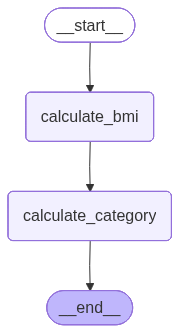

In [44]:

graph = StateGraph(BMIState)

graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('calculate_category', calculate_category)
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'calculate_category')
graph.add_edge('calculate_category', END)

workflow = graph.compile()

workflow

In [45]:
data = { "height": 1.75, "weight": 70 }
workflow.invoke(data)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal'}